# ДЗ №4 — Линейная регрессия (Life Expectancy)

**Датасет:** ожидаемая продолжительность жизни и показатели здравоохранения по странам и годам (WHO / Kaggle: *Life Expectancy Data*).

**Задача регрессии:** предсказать **`Life expectancy`** по экономическим и медицинским признакам.

**Формат:** панельные данные — несколько строк на одну страну (разные годы); в таблице есть числовые и категориальный признак `Status` (Developing / Developed).

## 2. EDA и предобработка

**Как предобрабатывали данные?** После загрузки убрали лишние пробелы в названиях колонок, посчитали пропуски и для числовых признаков использовали заполнение медианой (чтобы не «тянуть» выбросы), категории — наиболее частым значением; перед линейными моделями числовые признаки масштабировали.

**Что поняли из EDA?** Целевая переменная имеет примерно унимодальное распределение; есть пропуски в части признаков; часть признаков сильно коррелирует с целевой (например, образование и индекс ресурсов), есть признаки с выбросами и перекосом (GDP, Population).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
CSV_PATH = "life_expectancy_data.csv"  

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

TARGET = "Life expectancy"
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.shape, df.dtypes

((2938, 22),
 Country                                str
 Year                                 int64
 Status                                 str
 Life expectancy                    float64
 Adult Mortality                    float64
 infant deaths                        int64
 Alcohol                            float64
 percentage expenditure             float64
 Hepatitis B                        float64
 Measles                              int64
 BMI                                float64
 under-five deaths                    int64
 Polio                              float64
 Total expenditure                  float64
 Diphtheria                         float64
 HIV/AIDS                           float64
 GDP                                float64
 Population                         float64
 thinness  1-19 years               float64
 thinness 5-9 years                 float64
 Income composition of resources    float64
 Schooling                          float64
 dtype: object)

In [4]:
df.isna().sum().sort_values(ascending=False).head(20)

Population                         652
Hepatitis B                        553
GDP                                448
Total expenditure                  226
Alcohol                            194
Income composition of resources    167
Schooling                          163
thinness 5-9 years                  34
thinness  1-19 years                34
BMI                                 34
Polio                               19
Diphtheria                          19
Life expectancy                     10
Adult Mortality                     10
HIV/AIDS                             0
Country                              0
Year                                 0
Measles                              0
percentage expenditure               0
infant deaths                        0
dtype: int64

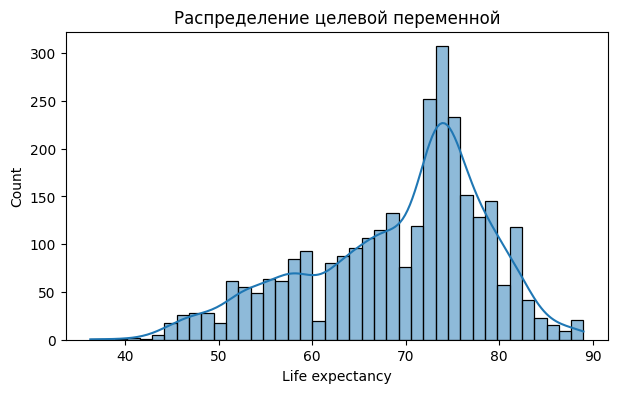

In [5]:
df[TARGET].describe()
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df[TARGET].dropna(), bins=40, kde=True, ax=ax)
ax.set_title("Распределение целевой переменной")
plt.show()

In [6]:
num = df.select_dtypes(include=[np.number]).columns
corr_target = df[num].corr(numeric_only=True)[TARGET].sort_values(ascending=False)
print(corr_target)

Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Year                               0.170033
Population                        -0.021538
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
thinness 5-9 years                -0.471584
thinness  1-19 years              -0.477183
HIV/AIDS                          -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy, dtype: float64


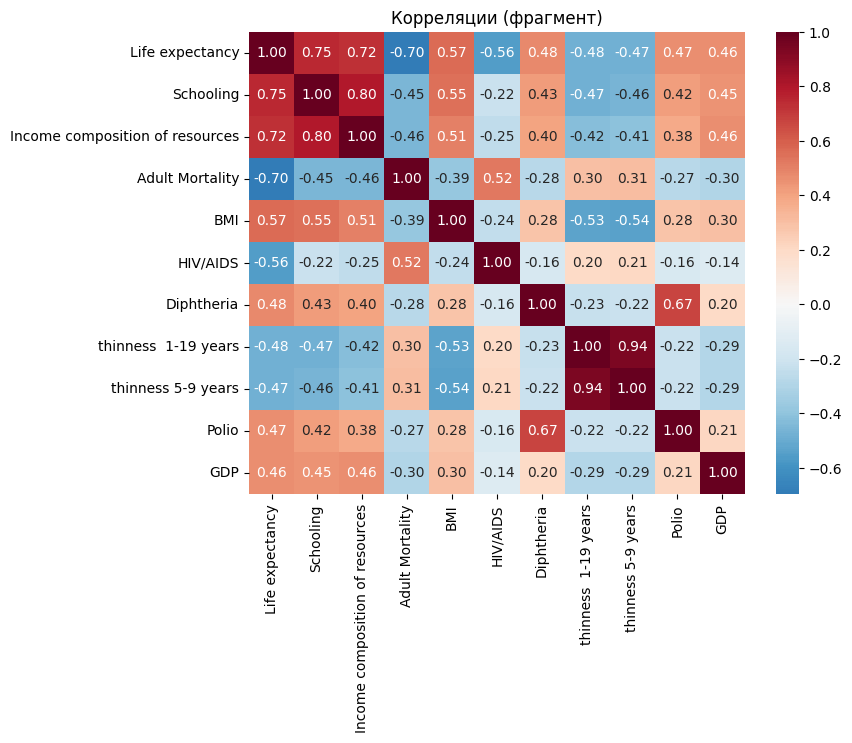

In [7]:
plt.figure(figsize=(8, 6))
cols_top = [TARGET] + corr_target.drop(TARGET).abs().nlargest(10).index.tolist()
sns.heatmap(df[cols_top].corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Корреляции (фрагмент)")
plt.show()

## 3. Feature Engineering

**Как работали с признаками?** Отделили матрицу признаков от целевой, выделили числовые и категориальный столбцы, задали единый `Pipeline` с импутацией, one-hot для `Status` и стандартизацией чисел.

**Что добавили / изменили?** Категорию `Status` закодировали через `OneHotEncoder` (для линейной модели это два бинарных признака с фиктивным уровнем); числовые признаки не расширяли полиномиально, чтобы не раздувать размерность без явной необходимости.

**Что удалили?** Столбец `Country` убрали из признаков: слишком много уникальных значений, one-hot «раздует» модель и даёт плохую обобщающую способность на train/test; год и агрегированные показатели уже отражают динамику.

## 4. Разделение данных

**Как разделили выборку?** Случайное разбиение **80% train / 20% test** с `random_state=42` для воспроизводимости.

**Зачем это нужно?** Часть данных держим «закрытой» для финальной оценки: на train подбираем коэффициенты и гиперпараметры, на test проверяем качество на новых объектах. Если обучать и мерить на одном наборе, метрики завышаются (модель «подстраивается под шум»), и нельзя честно оценить обобщение.

In [12]:
TARGET = "Life expectancy"   
df = df.dropna(subset=[TARGET]).copy()
print("Строк после удаления пропусков в целевой:", len(df))

Строк после удаления пропусков в целевой: 2928


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV

X = df.drop(columns=[TARGET, "Country"])
y = df[TARGET]

cat_cols = ["Status"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((2342, 20), (586, 20))

## 5. Обучение моделей

**Как проходило обучение?** Базовая **`LinearRegression`** в `Pipeline` с предобработкой; для **`Ridge`** и **`Lasso`** использовали **`GridSearchCV`** с 5-кратной кросс-валидацией на train, подбирали `alpha` по сетке (логарифмическая шкала).

**Сравнение скорости:** Обычно быстрее всего одна подгонка **`LinearRegression`** (аналитическое решение). **`GridSearchCV`** для Ridge/Lasso делает много обучений на разных `alpha` и фолдах, поэтому занимает больше времени; **`Lasso`** может быть чуть медленнее одного Ridge при том же числе итераций из-за особенностей оптимизации. *(После запуска ячейки с `%time` подставьте свои числа.)*

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics_report(name, model, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    for split, y_true, pred in [("Train", y_tr, pred_tr), ("Test", y_te, pred_te)]:
        mse = mean_squared_error(y_true, pred)
        print(f"{name} [{split}]  MSE={mse:.4f}  RMSE={np.sqrt(mse):.4f}  MAE={mean_absolute_error(y_true, pred):.4f}  R²={r2_score(y_true, pred):.4f}")

In [15]:
lin_pipe = Pipeline([("prep", preprocess), ("model", LinearRegression())])
%time lin_pipe.fit(X_train, y_train)
metrics_report("LinearRegression", lin_pipe, X_train, y_train, X_test, y_test)

CPU times: user 20.4 ms, sys: 24.8 ms, total: 45.2 ms
Wall time: 60.3 ms
LinearRegression [Train]  MSE=16.4841  RMSE=4.0601  MAE=3.0312  R²=0.8202
LinearRegression [Test]  MSE=15.6142  RMSE=3.9515  MAE=2.9273  R²=0.8195


In [16]:
ridge_pipe = Pipeline([("prep", preprocess), ("model", Ridge(random_state=RANDOM_STATE))])
param_ridge = {"model__alpha": np.logspace(-3, 3, 25)}
%time ridge_gs = GridSearchCV(ridge_pipe, param_ridge, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
ridge_gs.fit(X_train, y_train)
print("Лучший alpha (Ridge):", ridge_gs.best_params_)
metrics_report("Ridge", ridge_gs.best_estimator_, X_train, y_train, X_test, y_test)

CPU times: user 37 μs, sys: 343 μs, total: 380 μs
Wall time: 492 μs
Лучший alpha (Ridge): {'model__alpha': np.float64(0.31622776601683794)}
Ridge [Train]  MSE=16.4855  RMSE=4.0602  MAE=3.0310  R²=0.8202
Ridge [Test]  MSE=15.6181  RMSE=3.9520  MAE=2.9262  R²=0.8194


In [17]:
lasso_pipe = Pipeline([("prep", preprocess), ("model", Lasso(random_state=RANDOM_STATE, max_iter=50000))])
param_lasso = {"model__alpha": np.logspace(-4, 1, 25)}
%time lasso_gs = GridSearchCV(lasso_pipe, param_lasso, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
lasso_gs.fit(X_train, y_train)
print("Лучший alpha (Lasso):", lasso_gs.best_params_)
metrics_report("Lasso", lasso_gs.best_estimator_, X_train, y_train, X_test, y_test)

CPU times: user 27 μs, sys: 83 μs, total: 110 μs
Wall time: 129 μs
Лучший alpha (Lasso): {'model__alpha': np.float64(0.0028729848333536655)}
Lasso [Train]  MSE=16.4899  RMSE=4.0608  MAE=3.0303  R²=0.8202
Lasso [Test]  MSE=15.6211  RMSE=3.9524  MAE=2.9244  R²=0.8194


## 6. Метрики, сравнение и переобучение

**1. Какие метрики использовали?** **MSE / RMSE** — в тех же единицах, что и целевая (годы жизни), штрафуют большие ошибки сильнее; **MAE** — устойчивее к выбросам, интерпретируется как средняя ошибка в годах; **R²** показывает долю объяснённой дисперсии относительно «наивного» среднего — удобно для сравнения моделей на одной задаче.

**2. На какой части считали метрики?** Итоговое сравнение моделей — на **отложенной тестовой выборке (20%)**; при подборе `alpha` использовали **кросс-валидацию только на train**.

**3. Какая модель лучше?** *По тесту чуть лучше обычная линейная регрессия: у неё меньший RMSE и чуть выше R², чем у Ridge и Lasso. На практике все три модели почти эквивалентны — регуляризация почти не улучшила качество, значит сильного переобучения базовой модели на этих данных и признаках не видно.)*

**4. Насколько хорошие результаты?** *На тесте RMSE ≈ 3,95 года и MAE ≈ 2,93 года: в среднем модель ошибается примерно на 3 года по квадратичной метрике и на ~3 года по средней абсолютной ошибке. Для ожидаемой продолжительности жизни (типичный диапазон порядка 50–85 лет) такая ошибка умеренная: это не идеальный точечный прогноз, но для агрегированной модели по странам и годам приемлемый уровень. R² ≈ 0,82 означает, что модель объясняет около 82% разброса целевой переменной на отложенной выборке — это довольно высокое качество для линейной регрессии на таких данных.*

**5. Переобучение:** По metrics_report у всех трёх моделей RMSE на test (~3,95) даже чуть ниже, чем RMSE на train (~4,06), R² на train и test почти совпадает (~0,82). То есть нет типичной картины переобучения, когда ошибка на train сильно меньше, чем на test. Небольшая разница train/test и сопоставимость метрик говорят, что модель обобщается на отложенную выборку; Ridge/Lasso почти не меняют качество относительно обычной регрессии — регуляризация здесь не критична, признак того, что базовая линейная модель не сильно «запоминает» шум на этих признаках.

In [18]:
rows = []
for name, model in [
    ("LinearRegression", lin_pipe),
    ("Ridge", ridge_gs.best_estimator_),
    ("Lasso", lasso_gs.best_estimator_),
]:
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rows.append({
        "model": name,
        "RMSE_test": np.sqrt(mse),
        "MAE_test": mean_absolute_error(y_test, pred),
        "R2_test": r2_score(y_test, pred),
    })
pd.DataFrame(rows).sort_values("RMSE_test")

,model,RMSE_test,MAE_test,R2_test
0,LinearRegression,3.951483,2.927327,0.819488
1,Ridge,3.951974,2.926190,0.819443
2,Lasso,3.952352,2.924364,0.819408


## Итог

В ноутбуке: 
1 описание датасета и задачи; 
2 EDA и предобработка с ответами на вопросы; 
3 инженерия признаков и обоснование удаления `Country`; 
4 разделение train/test и зачем оно; 
5 обучение `LinearRegression`, `Ridge`, `Lasso` с подбором `alpha` и замечание о скорости; 
6 метрики MSE/RMSE/MAE/R² на test, сравнение моделей и аргументы про переобучение по train vs test и CV.